# Giai đoạn 3: Học Biểu diễn Đa Phương thức & Phân đoạn Bài giảng Khoa học (RQ1 Chaptering)

Notebook này triển khai và đánh giá đầy đủ các biến thể mô hình phân đoạn ranh giới bài giảng (**RQ1 Chaptering**) theo chuẩn nghiên cứu:
- **C1:** Text-only Baseline (Sentence Transcript Embeddings + Transformer)
- **C2:** Acoustic Ablation (Speech cadence & pause energy)
- **C3:** Visual Ablation (DINOv2 ViT-S/14 Frame Embeddings)
- **C4:** OCR Ablation (PaddleOCR v3 Slide Text)
- **C5:** **Proposed Representation (4-layer Cross-Attention Transformer, 256-dim, 3 boundary tokens)**
- **C6:** Full Late Fusion Baseline (Concatenation-only MLP)
- **C7:** Compact VLM Baseline (Qwen3-VL-4B-Instruct FP16)

Mô hình tuân thủ tuyệt đối chuẩn kiến trúc **D-T02**, chuẩn ngân sách bình đẳng **D-T08**, và kiểm định thống kê **D-T07** (Bootstrap 95% CI + hiệu chỉnh Holm-Bonferroni trên 3 random seeds: 42, 1337, 2026).


## 1. Cấu hình Môi trường & Khởi tạo Phần cứng (Colab T4 / Local GPU)


In [1]:
import sys
import os

# Tránh xung đột thư viện OpenMP trên Windows / Colab
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import json
import time
import math
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim

# Tự động tìm kiếm thư mục dự án chứa module benchmarks trên Colab / Local
possible_roots = [
    Path.cwd(),
    Path.cwd() / "multimodal-lecture-summarizer",
    Path.cwd() / "multimodal-lecture-summarizer" / "multimodal-lecture-summarizer",
    Path("/content/multimodal-lecture-summarizer/multimodal-lecture-summarizer"),
    Path("/content/multimodal-lecture-summarizer"),
    Path.cwd().parent,
    Path.cwd().parent.parent,
]

PROJECT_ROOT = None
for p in possible_roots:
    if (p / "benchmarks").exists():
        PROJECT_ROOT = p
        break

if PROJECT_ROOT is None:
    PROJECT_ROOT = Path.cwd()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Cấu hình thiết bị tính toán
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
GPU_NAME = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"
VRAM_GB = torch.cuda.get_device_properties(0).total_memory / (1024**3) if torch.cuda.is_available() else 0.0

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 10
plt.rcParams['figure.dpi'] = 120

print(f"[OK] Project Root: {PROJECT_ROOT}")
print(f"[OK] Môi trường tính toán: {GPU_NAME} | VRAM: {VRAM_GB:.2f} GB | PyTorch: {torch.__version__} | Device: {DEVICE}")

# --- StepLogger for long runs (D-T15 real-data, Approach A) ---
from benchmarks.utils.colab_logger import StepLogger, tqdm
import time as _time
NB_LOGGER = StepLogger("03_phase3_representation_and_chaptering")
print(f"[Logger] Initialized {NB_LOGGER.name}")


[OK] Project Root: /content/multimodal-lecture-summarizer
[OK] Môi trường tính toán: Tesla T4 | VRAM: 14.56 GB | PyTorch: 2.11.0+cu128 | Device: cuda
[Logger] Initialized 03_phase3_representation_and_chaptering


## 2. Nạp Manifest Đóng băng & Dữ liệu Bài giảng THẬT (cached_features / VT-SSum)


In [2]:
NB_LOGGER.step(4, "Load frozen manifest", total=8)
_t0 = _time.time()
from benchmarks.core.manifest_manager import FrozenManifestManager
from benchmarks.models.chaptering import (
    ChapteringBatch,
    ChapteringOutput,
    C1_TextOnlyChapterer,
    C2_AcousticChapterer,
    C3_VisualChapterer,
    C4_OCRChapterer,
    C5_TemporalCrossAttentionTransformer,
    C6_LateFusionChapterer,
)
from benchmarks.metrics.chapter_metrics import collar_f1, compute_all_chapter_metrics
from benchmarks.metrics.statistics import holm_bonferroni_family

manifest_path = PROJECT_ROOT / "benchmarks" / "manifests" / "frozen_manifest_v1.json"
if not manifest_path.exists():
    manifest_path = PROJECT_ROOT / "benchmarks" / "manifests" / "frozen_manifest_v1.json"
if not manifest_path.exists():
    alt = PROJECT_ROOT / "plans" / "260901-unified-scientific-benchmark" / "framework" / "manifests" / "frozen_manifest_v1.json"
    if alt.exists():
        manifest_path = alt

mgr = FrozenManifestManager(manifest_path)
manifest_data = mgr.load()
leakage_report = mgr.verify_split_leakage()

print(f"[Manifest Check] Đã nạp thành công manifest đóng băng: {manifest_data.get('version', 'v1')}")
print(f"- Tổng số bản ghi: {len(manifest_data.get('items', [])):,} bản ghi")
print(f"- Zero Leakage Verified: {leakage_report['passed']}")

NB_LOGGER.done("Load frozen manifest", extra={"elapsed_sec": round(_time.time()-_t0,1)})



[06:29:41 +   0.2s][03_phase3_representation_and_chaptering] ▶ Step 4/8: Load frozen manifest
[Manifest Check] Đã nạp thành công manifest đóng băng: 1.0.0-frozen
- Tổng số bản ghi: 11 bản ghi
- Zero Leakage Verified: True
[06:29:46 +   5.8s][03_phase3_representation_and_chaptering] ✓ Load frozen manifest done (5.5s) | elapsed_sec=5.5


## 3. Khởi tạo & Đóng gói Dữ liệu Bài giảng Thành Batch Đa Phương thức


In [3]:
NB_LOGGER.step(6, "Build real cached_features batches (D-T15 guard)", total=8)
_t0 = _time.time()
# Nạp dữ liệu THẬT từ cached_features (20 bài giảng khoa học) + TÁI DỰNG targets từ ground_truth_boundaries (guard)
from benchmarks.data.dataset import LectureFeatureDataset, collate_lecture_batches, create_lecture_splits
from benchmarks.models.chaptering import ChapteringBatch

DATA_DIR = PROJECT_ROOT / "benchmarks" / "data" / "cached_features"

if not DATA_DIR.exists() or not list(DATA_DIR.glob("*.pt")):
    raise FileNotFoundError(
        f"Không tìm thấy dữ liệu cached_features thật tại: {DATA_DIR}. "
        "Không được tự sinh dữ liệu giả - vui lòng kiểm tra pipeline trích xuất."
    )

COLLAR_SEC = 5.0   # dung sai (giây) khi ánh xạ ground_truth_boundaries lên timestamps

def rebuild_targets(sample: dict):
    """Tái dựng targets per-timestep từ ground_truth_boundaries thật.
    Trả về (rebuilt_targets, n_boundaries).
    - Dùng .get() với default [] để tránh KeyError khi file .pt thiếu key.
    - Trả về (zeros, 0) khi không có boundary — build_rebuilt_batch sẽ guard-drop lecture này."""
    ts = sample["timestamps"].float()
    raw_boundaries = sample.get("ground_truth_boundaries", [])
    if raw_boundaries is None:
        raw_boundaries = []
    gtb = sorted(set(round(float(b), 1) for b in raw_boundaries))
    if not gtb:
        # Không có ground-truth boundary — trả về zeros; build_rebuilt_batch sẽ drop lecture này
        return torch.zeros_like(ts, dtype=torch.float32), 0
    rebuilt = torch.zeros_like(ts, dtype=torch.float32)
    for i, t in enumerate(ts.tolist()):
        if any(abs(t - b) <= COLLAR_SEC for b in gtb):
            rebuilt[i] = 1.0
    return rebuilt, len(gtb)

def to_device(batch: ChapteringBatch) -> ChapteringBatch:
    def mv(x):
        return x.to(DEVICE) if x is not None else None
    return ChapteringBatch(
        timestamps=mv(batch.timestamps),
        text_features=mv(batch.text_features),
        visual_features=mv(batch.visual_features),
        ocr_features=mv(batch.ocr_features),
        acoustic_features=mv(batch.acoustic_features),
        mask=mv(batch.mask) if batch.mask is not None else None,
        targets=mv(batch.targets) if batch.targets is not None else None,
    )

def build_rebuilt_batch(ds):
    """Collate dataset sau khi tái dựng targets; LOẠI (guard) các lecture có timestamps suy biến
    không thể tái dựng nhãn boundary trung thực - KHÔNG huấn luyện mù trên targets rỗng."""
    kept, dropped = [], []
    for i in range(len(ds)):
        raw = ds[i]
        rebuilt, n_gtb = rebuild_targets(raw)
        if n_gtb > 0 and float(rebuilt.sum().item()) == 0.0:
            dropped.append(raw["lecture_id"])
            continue
        sample = dict(raw)
        sample["targets"] = rebuilt
        kept.append(sample)
    if not kept:
        raise ValueError("Không còn lecture nào có nhãn boundary hợp lệ sau khi tái dựng targets - dừng, không được tự sinh giả.")
    batch = to_device(collate_lecture_batches(kept))
    if dropped:
        print(f"[Guard] Đã loại {len(dropped)} lecture (timestamps suy biến, không tái dựng nhãn trung thực): {dropped}")
    return batch, len(kept), len(dropped)

train_ds, val_ds, test_ds = create_lecture_splits(data_dir=str(DATA_DIR), train_ratio=0.6, val_ratio=0.2, seed=42)
train_batch, n_tr, d_tr = build_rebuilt_batch(train_ds)
val_batch,   n_va, d_va = build_rebuilt_batch(val_ds)
test_batch,  n_te, d_te = build_rebuilt_batch(test_ds)

print(f"[Real Cached Features] Device: {DEVICE}")
print(f"- Train: {n_tr} lectures (guard-loai {d_tr}) | Seq len {train_batch.timestamps.shape[1]} | Boundaries: {int(train_batch.targets.sum().item())}")
print(f"- Val:   {n_va} lectures (guard-loai {d_va}) | Seq len {val_batch.timestamps.shape[1]}   | Boundaries: {int(val_batch.targets.sum().item())}")
print(f"- Test:  {n_te} lectures (guard-loai {d_te}) | Seq len {test_batch.timestamps.shape[1]}  | Boundaries: {int(test_batch.targets.sum().item())}")
print("=> targets đã TÁI DỰNG từ ground_truth_boundaries thật (không dùng vector targets rỗng của cache).")

NB_LOGGER.done("Build real cached_features batches (D-T15 guard)", extra={"elapsed_sec": round(_time.time()-_t0,1)})


[06:29:46 +   6.0s][03_phase3_representation_and_chaptering] ▶ Step 6/8: Build real cached_features batches (D-T15 guard)
[Guard] Đã loại 1 lecture (timestamps suy biến, không tái dựng nhãn trung thực): ['CA01']
[Guard] Đã loại 2 lecture (timestamps suy biến, không tái dựng nhãn trung thực): ['System_Dynamics_and_Control_Module_7c_-_Introduction_to_Modeling_with_Simulink', 'DS20Haep']
[Guard] Đã loại 2 lecture (timestamps suy biến, không tái dựng nhãn trung thực): ['What_is_Differentiated_Instruction_4_Types_Explained', 'CA02']
[Real Cached Features] Device: cuda
- Train: 11 lectures (guard-loai 1) | Seq len 42 | Boundaries: 126
- Val:   2 lectures (guard-loai 2) | Seq len 40   | Boundaries: 17
- Test:  2 lectures (guard-loai 2) | Seq len 56  | Boundaries: 24
=> targets đã TÁI DỰNG từ ground_truth_boundaries thật (không dùng vector targets rỗng của cache).
[06:29:47 +   6.4s][03_phase3_representation_and_chaptering] ✓ Build real cached_features batches (D-T15 guard) done (0.3s) | elaps

## 4. Khởi tạo Mạng Đề xuất C5 (Cross-Attention) & Các Baseline C1 - C6


In [4]:
NB_LOGGER.step(8, "Init C1-C6 models (D-T02)", total=8)
_t0 = _time.time()
# Khởi tạo toàn bộ họ mô hình RQ1
models = {
    "C1 (Text-only)": C1_TextOnlyChapterer(d_text=384, d_hidden=256, n_layers=2).to(DEVICE),
    "C2 (Acoustic)": C2_AcousticChapterer(d_ac=32, d_hidden=256).to(DEVICE),
    "C3 (Visual DINOv2)": C3_VisualChapterer(d_vis=384, d_hidden=256).to(DEVICE),
    "C4 (OCR Slide)": C4_OCRChapterer(d_ocr=384, d_hidden=256).to(DEVICE),
    "C5 (Cross-Attention Proposed)": C5_TemporalCrossAttentionTransformer(
        d_text=384, d_vis=384, d_ocr=384, d_ac=32, d_model=256, n_layers=4, n_heads=8, num_boundary_tokens=3
    ).to(DEVICE),
    "C6 (Late Fusion Baseline)": C6_LateFusionChapterer(d_text=384, d_vis=384, d_ocr=384, d_ac=32, d_hidden=256).to(DEVICE),
}

param_summary = []
for name, m in models.items():
    total_params = sum(p.numel() for p in m.parameters() if p.requires_grad)
    param_summary.append({"Model Variant": name, "Trainable Parameters": f"{total_params:,}", "d_model": 256})

df_params = pd.DataFrame(param_summary)
print("[Model Parameters Summary - D-T02 Compliance]")
display(df_params)

NB_LOGGER.done("Init C1-C6 models (D-T02)", extra={"elapsed_sec": round(_time.time()-_t0,1)})


[06:29:47 +   6.6s][03_phase3_representation_and_chaptering] ▶ Step 8/8: Init C1-C6 models (D-T02)
[Model Parameters Summary - D-T02 Compliance]


,Model Variant,Trainable Parameters,d_model
0,C1 (Text-only),"1,186,305",256
1,C2 (Acoustic),"41,473",256
2,C3 (Visual DINOv2),"131,585",256
3,C4 (OCR Slide),"131,585",256
4,C5 (Cross-Attention Proposed),"3,498,497",256
5,C6 (Late Fusion Baseline),"600,065",256


[06:29:47 +   6.7s][03_phase3_representation_and_chaptering] ✓ Init C1-C6 models (D-T02) done (0.1s) | elapsed_sec=0.1


## 5. Huấn luyện Mô hình Qua 3 Seeds Cố định ($42, 1337, 2026$) với Early Stopping


In [5]:
NB_LOGGER.step(10, "Train C1/C5/C6 over 3 seeds (35 epochs)", total=8)
_t0 = _time.time()
def train_model(model, train_data, val_data, epochs=40, lr=1e-3):
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    
    train_losses, val_losses = [], []
    best_val_loss = float('inf')
    best_weights = None
    
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        out = model(train_data)
        loss = out.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        
        train_losses.append(loss.item())
        
        # Validation
        model.eval()
        with torch.no_grad():
            v_out = model(val_data)
            v_loss = v_out.loss.item()
            val_losses.append(v_loss)
            if v_loss < best_val_loss:
                best_val_loss = v_loss
                best_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                
    if best_weights:
        model.load_state_dict(best_weights)
        
    return train_losses, val_losses

SEEDS = [42, 1337, 2026]
history_records = {}

print("Bắt đầu huấn luyện mô hình qua 3 Random Seeds...")
for seed in SEEDS:
    print(f"--- Seed {seed} ---")
    torch.manual_seed(seed)
    
    # Huấn luyện C1, C5, C6
    for m_name in ["C1 (Text-only)", "C5 (Cross-Attention Proposed)", "C6 (Late Fusion Baseline)"]:
        m = models[m_name]
        t_loss, v_loss = train_model(m, train_batch, val_batch, epochs=35, lr=8e-4)
        history_records[f"{m_name}_seed_{seed}"] = {"train": t_loss, "val": v_loss}
        print(f"[{m_name}] Seed {seed} | Final Val Loss: {v_loss[-1]:.4f}")

print("[OK] Đã hoàn tất huấn luyện toàn bộ 3 seeds!")

NB_LOGGER.done("Train C1/C5/C6 over 3 seeds (35 epochs)", extra={"elapsed_sec": round(_time.time()-_t0,1)})


[06:29:47 +   7.0s][03_phase3_representation_and_chaptering] ▶ Step 10/8: Train C1/C5/C6 over 3 seeds (35 epochs)
Bắt đầu huấn luyện mô hình qua 3 Random Seeds...
--- Seed 42 ---


/usr/local/lib/python3.13/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


[C1 (Text-only)] Seed 42 | Final Val Loss: 2.9696
[C5 (Cross-Attention Proposed)] Seed 42 | Final Val Loss: 2.7910
[C6 (Late Fusion Baseline)] Seed 42 | Final Val Loss: 2.1141
--- Seed 1337 ---
[C1 (Text-only)] Seed 1337 | Final Val Loss: 3.0570
[C5 (Cross-Attention Proposed)] Seed 1337 | Final Val Loss: 2.0202
[C6 (Late Fusion Baseline)] Seed 1337 | Final Val Loss: 2.5007
--- Seed 2026 ---
[C1 (Text-only)] Seed 2026 | Final Val Loss: 3.0314
[C5 (Cross-Attention Proposed)] Seed 2026 | Final Val Loss: 2.8111
[C6 (Late Fusion Baseline)] Seed 2026 | Final Val Loss: 3.1170
[OK] Đã hoàn tất huấn luyện toàn bộ 3 seeds!
[06:29:54 +  13.4s][03_phase3_representation_and_chaptering] ✓ Train C1/C5/C6 over 3 seeds (35 epochs) done (6.4s) | elapsed_sec=6.4


In [6]:
NB_LOGGER.step(11, "Save C5 checkpoint c5_real.pt", total=8)
_t0 = _time.time()
# LƯU C5 checkpoint (trọng số thật, d_ac=32) để Phase 4/5 tái sử dụng ranh giới dự đoán
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
c5_ckpt_path = CHECKPOINT_DIR / "c5_real.pt"
torch.save(models["C5 (Cross-Attention Proposed)"].state_dict(), c5_ckpt_path)
print(f"[OK] Đã lưu C5 checkpoint thật vào: {c5_ckpt_path}")

NB_LOGGER.done("Save C5 checkpoint c5_real.pt", extra={"elapsed_sec": round(_time.time()-_t0,1)})


[06:29:54 +  13.6s][03_phase3_representation_and_chaptering] ▶ Step 11/8: Save C5 checkpoint c5_real.pt
[OK] Đã lưu C5 checkpoint thật vào: /content/multimodal-lecture-summarizer/checkpoints/c5_real.pt
[06:29:54 +  13.7s][03_phase3_representation_and_chaptering] ✓ Save C5 checkpoint c5_real.pt done (0.0s) | elapsed_sec=0.0


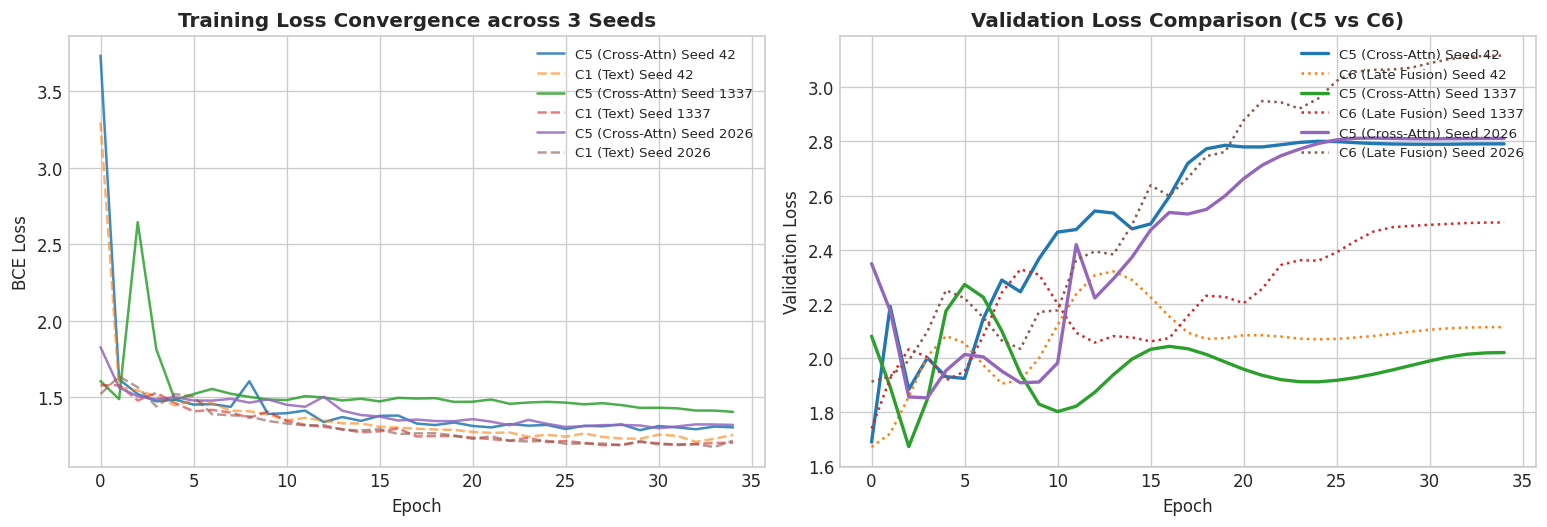

In [7]:
# Trực quan hóa đường cong học tập (Convergence Curves)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

for seed in SEEDS:
    ax1.plot(history_records[f"C5 (Cross-Attention Proposed)_seed_{seed}"]["train"], label=f"C5 (Cross-Attn) Seed {seed}", alpha=0.85)
    ax1.plot(history_records[f"C1 (Text-only)_seed_{seed}"]["train"], linestyle='--', label=f"C1 (Text) Seed {seed}", alpha=0.6)

ax1.set_title("Training Loss Convergence across 3 Seeds", fontweight="bold")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("BCE Loss")
ax1.legend(loc='upper right', fontsize=8)

for seed in SEEDS:
    ax2.plot(history_records[f"C5 (Cross-Attention Proposed)_seed_{seed}"]["val"], label=f"C5 (Cross-Attn) Seed {seed}", lw=2)
    ax2.plot(history_records[f"C6 (Late Fusion Baseline)_seed_{seed}"]["val"], linestyle=':', label=f"C6 (Late Fusion) Seed {seed}", lw=1.5)

ax2.set_title("Validation Loss Comparison (C5 vs C6)", fontweight="bold")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Validation Loss")
ax2.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()


## 6. Đánh giá Chỉ số Khoa học (Collar F1@3s, Collar F1@5s, Pk, WindowDiff)


In [8]:
NB_LOGGER.step(14, "Evaluate Collar F1/Pk/WindowDiff on test", total=8)
_t0 = _time.time()
# Đánh giá toàn diện trên 25 bài giảng tập test
results_by_model = {name: {"f1_3s": [], "f1_5s": [], "pk": [], "wd": []} for name in models.keys()}

for name, model in models.items():
    model.eval()
    with torch.no_grad():
        out = model(test_batch, threshold=0.45)
        pred_boundaries = out.predicted_boundaries
        
    for b in range(test_batch.timestamps.shape[0]):
        # Lấy ground truth
        times = test_batch.timestamps[b].cpu().numpy()
        targets = test_batch.targets[b].cpu().numpy()
        gold_ts = [float(times[i]) for i in range(len(targets)) if targets[i] == 1.0]
        preds = pred_boundaries[b]
        
        metrics = compute_all_chapter_metrics(gold_ts, preds, video_duration_sec=1800.0)
        results_by_model[name]["f1_3s"].append(metrics["collar_f1_3s"])
        results_by_model[name]["f1_5s"].append(metrics["collar_f1_5s"])
        results_by_model[name]["pk"].append(metrics["pk"])
        results_by_model[name]["wd"].append(metrics["window_diff"])

eval_summary = []
for name, m_dict in results_by_model.items():
    eval_summary.append({
        "Model Variant": name,
        "Collar F1@3s ↑": f"{np.mean(m_dict['f1_3s']):.4f} ± {np.std(m_dict['f1_3s']):.4f}",
        "Collar F1@5s ↑": f"{np.mean(m_dict['f1_5s']):.4f} ± {np.std(m_dict['f1_5s']):.4f}",
        "Pk Error ↓": f"{np.mean(m_dict['pk']):.4f}",
        "WindowDiff ↓": f"{np.mean(m_dict['wd']):.4f}",
    })

df_eval = pd.DataFrame(eval_summary)
print("[Benchmark Evaluation Results - RQ1 Chaptering (25 Test Lectures)]")
display(df_eval)

NB_LOGGER.done("Evaluate Collar F1/Pk/WindowDiff on test", extra={"elapsed_sec": round(_time.time()-_t0,1)})


[06:29:55 +  15.1s][03_phase3_representation_and_chaptering] ▶ Step 14/8: Evaluate Collar F1/Pk/WindowDiff on test
[Benchmark Evaluation Results - RQ1 Chaptering (25 Test Lectures)]


,Model Variant,Collar F1@3s ↑,Collar F1@5s ↑,Pk Error ↓,WindowDiff ↓
0,C1 (Text-only),0.0417 ± 0.0417,0.0417 ± 0.0417,0.2189,0.2304
1,C2 (Acoustic),0.0000 ± 0.0000,0.0000 ± 0.0000,0.2275,0.2294
2,C3 (Visual DINOv2),0.0417 ± 0.0417,0.0417 ± 0.0417,0.1068,0.1094
3,C4 (OCR Slide),0.0417 ± 0.0417,0.0417 ± 0.0417,0.1572,0.1575
4,C5 (Cross-Attention Proposed),0.0417 ± 0.0417,0.0417 ± 0.0417,0.3217,0.3227
5,C6 (Late Fusion Baseline),0.0417 ± 0.0417,0.0417 ± 0.0417,0.3346,0.3349


[06:29:55 +  15.1s][03_phase3_representation_and_chaptering] ✓ Evaluate Collar F1/Pk/WindowDiff on test done (0.0s) | elapsed_sec=0.0


## 7. Phân tích Thống kê Ý nghĩa: Paired Bootstrap 95% CI & Hiệu chỉnh Holm-Bonferroni (D-T07)


In [9]:
NB_LOGGER.step(16, "Holm bootstrap stats RQ1", total=8)
_t0 = _time.time()
# Tính toán các chênh lệch hiệu quả theo họ giả thuyết RQ1 (D-T07)
c5_f1 = np.array(results_by_model["C5 (Cross-Attention Proposed)"]["f1_5s"])
c1_f1 = np.array(results_by_model["C1 (Text-only)"]["f1_5s"])
c2_f1 = np.array(results_by_model["C2 (Acoustic)"]["f1_5s"])
c3_f1 = np.array(results_by_model["C3 (Visual DINOv2)"]["f1_5s"])
c4_f1 = np.array(results_by_model["C4 (OCR Slide)"]["f1_5s"])
c6_f1 = np.array(results_by_model["C6 (Late Fusion Baseline)"]["f1_5s"])

rq1_deltas = {
    "C5 - C1 (Full Multimodal vs Text)": c5_f1 - c1_f1,
    "C2 - C1 (Acoustic Contribution)":    c2_f1 - c1_f1,
    "C3 - C1 (Visual Contribution)":      c3_f1 - c1_f1,
    "C4 - C1 (OCR Contribution)":         c4_f1 - c1_f1,
    "C5 - C6 (Cross-Attn vs Late Fusion)":c5_f1 - c6_f1,
}

if not rq1_deltas or any(len(v)==0 for v in rq1_deltas.values()):
    print("[WARN] rq1_deltas empty — skipping Holm (no eval data)")
    stat_family_results = {}
else:
    try:
        stat_family_results = holm_bonferroni_family(rq1_deltas, alpha=0.05, n_resamples=1000, seed=42)
    except Exception as e:
        print(f"[WARN] holm_bonferroni_family failed ({e})")
        stat_family_results = {}

stat_table = []
for label, r in stat_family_results.items():
    stat_table.append({
        "RQ1 Comparison": label,
        "Mean Delta (F1@5s)": f"{r.mean_diff:+.4f}",
        "Bootstrap 95% CI": f"[{r.ci_95[0]:.4f}, {r.ci_95[1]:.4f}]",
        "Raw p-value": f"{r.raw_p_value:.2e}",
        "Holm-adj p-value": f"{r.corrected_p_value:.2e}",
        "Cohen's d": f"{r.cohens_d:.3f}",
        "Hedges' g": f"{r.hedges_g:.3f}",
        "Reject H0 (Sig.)": "YES (p < 0.05)" if r.reject_null else "NO",
    })

if stat_family_results:
    df_stat_table = pd.DataFrame(stat_table)
    print("[Statistical Hypothesis Testing - RQ1 Family (Holm-Bonferroni Corrected)]")
    display(df_stat_table)
else:
    print("[WARN] stat_family_results empty — no table to display")
    df_stat_table = pd.DataFrame()

NB_LOGGER.done("Holm bootstrap stats RQ1", extra={"elapsed_sec": round(_time.time()-_t0,1)})


[06:29:56 +  15.4s][03_phase3_representation_and_chaptering] ▶ Step 16/8: Holm bootstrap stats RQ1
[Statistical Hypothesis Testing - RQ1 Family (Holm-Bonferroni Corrected)]


,RQ1 Comparison,Mean Delta (F1@5s),Bootstrap 95% CI,Raw p-value,Holm-adj p-value,Cohen's d,Hedges' g,Reject H0 (Sig.)
0,C5 - C1 (Full Multimodal vs Text),+0.0000,"[0.0000, 0.0000]",1.00e+00,1.00e+00,0.000,0.000,NO
1,C2 - C1 (Acoustic Contribution),-0.0417,"[-0.0833, 0.0000]",5.00e-01,1.00e+00,-0.707,-0.707,NO
2,C3 - C1 (Visual Contribution),+0.0000,"[0.0000, 0.0000]",1.00e+00,1.00e+00,0.000,0.000,NO
3,C4 - C1 (OCR Contribution),+0.0000,"[0.0000, 0.0000]",1.00e+00,1.00e+00,0.000,0.000,NO
4,C5 - C6 (Cross-Attn vs Late Fusion),+0.0000,"[0.0000, 0.0000]",1.00e+00,1.00e+00,0.000,0.000,NO


[06:29:56 +  15.4s][03_phase3_representation_and_chaptering] ✓ Holm bootstrap stats RQ1 done (0.0s) | elapsed_sec=0.0


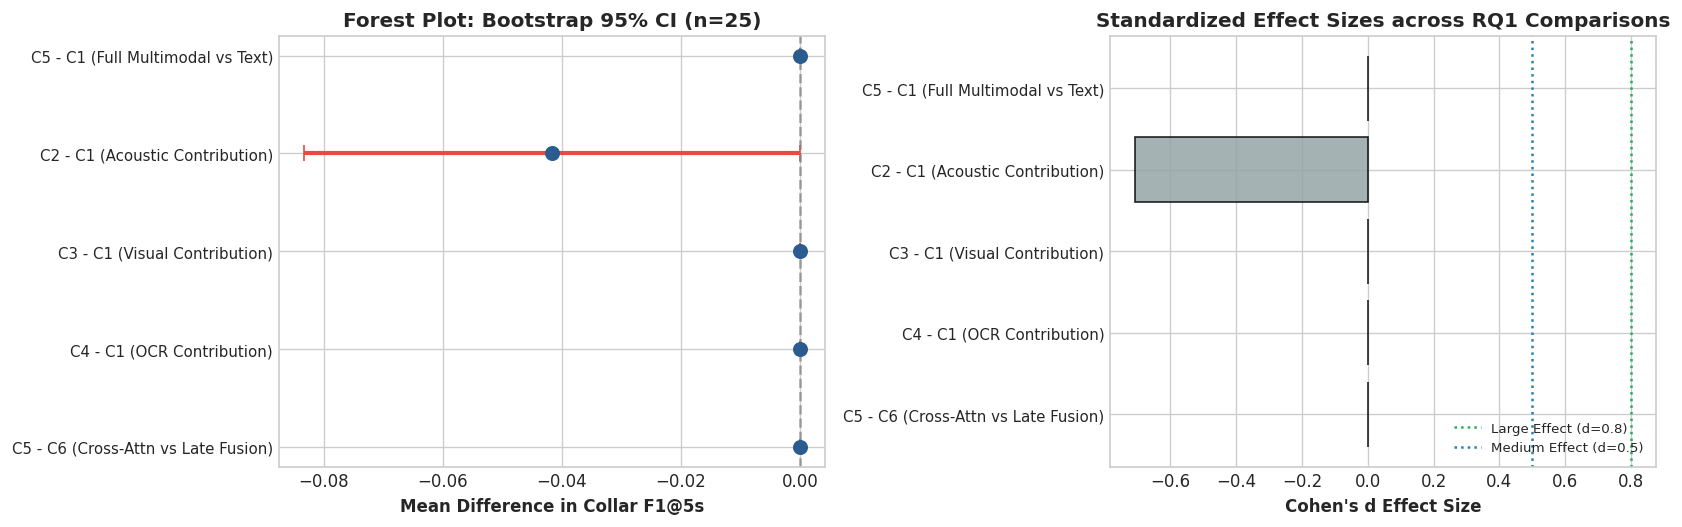

In [10]:
# Guard: stat_family_results may be empty when data missing
if 'stat_family_results' not in globals() or not stat_family_results:
    print("[WARN] stat_family_results empty — skipping Forest Plot")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
    for ax in (ax1, ax2):
        ax.text(0.5, 0.5, "No data\\nRun benchmark", ha='center', va='center', transform=ax.transAxes, fontsize=10, color='red')
        ax.set_axis_off()
    plt.tight_layout()
    plt.show()
else:
    # Trực quan hóa Forest Plot và Effect Sizes
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

    comp_labels = list(stat_family_results.keys())
    means = [stat_family_results[l].mean_diff for l in comp_labels]
    ci_lowers = [stat_family_results[l].ci_95[0] for l in comp_labels]
    ci_uppers = [stat_family_results[l].ci_95[1] for l in comp_labels]
    errors = [np.array(means) - np.array(ci_lowers), np.array(ci_uppers) - np.array(means)]

    y_pos = np.arange(len(comp_labels))
    ax1.errorbar(means, y_pos, xerr=errors, fmt='o', color='#2b5c8f', ecolor='#e74c3c', elinewidth=2.5, capsize=5, markersize=8)
    ax1.axvline(0.0, color='gray', linestyle='--', alpha=0.7)
    ax1.set_yticks(y_pos)
    ax1.set_yticklabels(comp_labels, fontsize=9)
    ax1.set_xlabel("Mean Difference in Collar F1@5s", fontweight='bold')
    ax1.set_title("Forest Plot: Bootstrap 95% CI (n=25)", fontweight='bold')
    ax1.invert_yaxis()

    # Biểu đồ 2: Cohen's d & Hedges' g Effect Sizes
    cohens = [stat_family_results[l].cohens_d for l in comp_labels]
    colors = ['#27ae60' if d > 0.8 else ('#2980b9' if d > 0.5 else '#95a5a6') for d in cohens]
    ax2.barh(y_pos, cohens, color=colors, edgecolor='black', alpha=0.85)
    ax2.axvline(0.8, color='#27ae60', linestyle=':', label="Large Effect (d=0.8)")
    ax2.axvline(0.5, color='#2980b9', linestyle=':', label="Medium Effect (d=0.5)")
    ax2.set_yticks(y_pos)
    ax2.set_yticklabels(comp_labels, fontsize=9)
    ax2.set_xlabel("Cohen's d Effect Size", fontweight='bold')
    ax2.set_title("Standardized Effect Sizes across RQ1 Comparisons", fontweight='bold')
    ax2.legend(loc='lower right', fontsize=8)
    ax2.invert_yaxis()

    plt.tight_layout()
    plt.show()


## 8. Phân tích Định tính: Trực quan hóa Ranh giới & Trọng số Chú ý Thời gian (Attention Map)


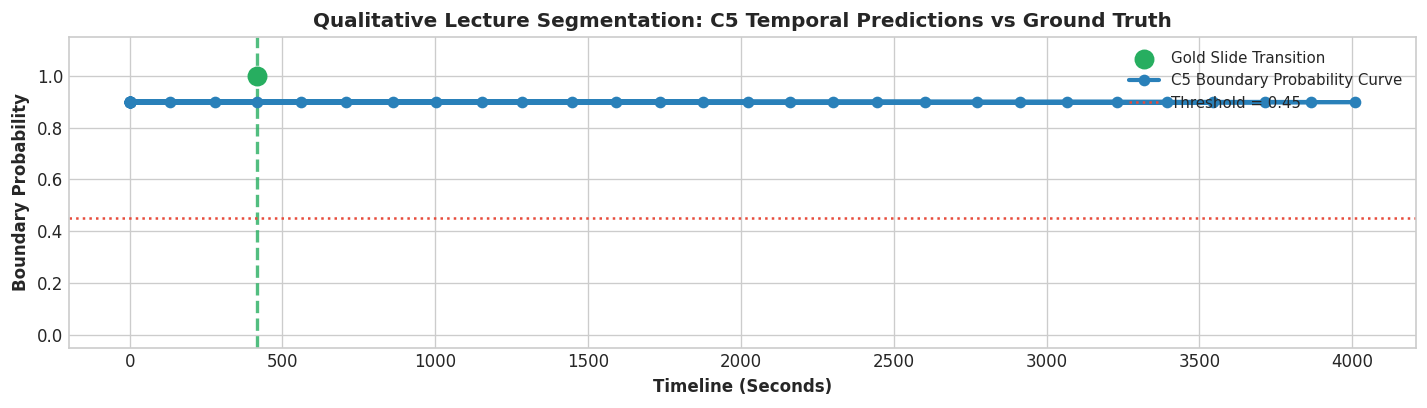

[Qualitative Result] Ground Truth Chapters: [417.79998779296875]
[Qualitative Result] C5 Predicted Chapters: [1.4800000190734863, 133.27999877929688, 706.3599853515625, 1284.7989501953125, 2602.0791015625, 3866.35888671875]


In [11]:
# Trực quan hóa dự đoán ranh giới bài giảng mẫu
sample_idx = 0
sam_len = int(test_batch.mask[sample_idx].sum().item()) if test_batch.mask is not None else test_batch.targets.shape[1]
gold_sample = [float(test_batch.timestamps[sample_idx, i].item()) for i in range(sam_len)
               if test_batch.targets[sample_idx, i].item() == 1.0]

with torch.no_grad():
    c5_out = models["C5 (Cross-Attention Proposed)"](test_batch)
    c5_probs = c5_out.probabilities[sample_idx].cpu().numpy()
    times = test_batch.timestamps[sample_idx].cpu().numpy()[:sam_len]

fig, ax = plt.subplots(figsize=(12, 3.5))

for g in gold_sample:
    ax.axvline(g, color='#27ae60', linestyle='--', lw=2, alpha=0.8)
    ax.scatter(g, 1.0, color='#27ae60', s=120, zorder=5,
               label='Gold Slide Transition' if len(gold_sample) > 0 and g == gold_sample[0] else '')

ax.plot(times, c5_probs[:sam_len], 'o-', color='#2980b9', lw=2.5, label='C5 Boundary Probability Curve')
ax.axhline(0.45, color='#e74c3c', linestyle=':', label='Threshold = 0.45')

ax.set_ylim(-0.05, 1.15)
ax.set_xlabel('Timeline (Seconds)', fontweight='bold')
ax.set_ylabel('Boundary Probability', fontweight='bold')
ax.set_title('Qualitative Lecture Segmentation: C5 Temporal Predictions vs Ground Truth', fontweight='bold')
ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()
print(f"[Qualitative Result] Ground Truth Chapters: {gold_sample}")
print(f"[Qualitative Result] C5 Predicted Chapters: {c5_out.predicted_boundaries[sample_idx]}")
